# 32 — Conservation Gap Analysis

Aggregate the per-species current flows (from the batch job submitted in
notebook 31) and GNN suitability scores into a multi-species priority surface,
then overlay with Swiss protected areas to quantify conservation gaps.

**Decisions made here**:
- How to normalise raw current flow per species (max vs p99 vs rank)
- How to weight species (equal vs threat-level-weighted)
- How to combine suitability and connectivity into a priority score

**Pipeline**:
1. Download batch job results from S3
2. Load current flows + suitability + species list
3. Choose normalisation strategy
4. Aggregate into a multi-species priority surface
5. Overlay with WDPA protected areas
6. Quantify: what fraction of high-priority patches are protected?

### Setup

In [1]:
import config
import numpy as np
import pandas as pd
import pickle
import os
import boto3
import matplotlib.pyplot as plt

with open('landscape_graph.pkl', 'rb') as f:
    G = pickle.load(f)

n_patches = G.number_of_nodes()
print(f'Graph: {n_patches:,} nodes, {G.number_of_edges():,} edges')

# --- Download batch job results from S3 ---
output_dir = 'gap_analysis_output'
os.makedirs(output_dir, exist_ok=True)

import sagemaker
import tarfile
import tempfile

s3 = boto3.client('s3')
sm = boto3.client('sagemaker')

# The SageMaker job packages /opt/ml/model/ into model.tar.gz
# Key files inside:
#   - current_flow_raw.npz
#   - current_flow_normed.npz
#   - gap_analysis_results.csv

result_files = [
    'current_flow_raw.npz',
    'current_flow_normed.npz',
    'gap_analysis_results.csv',
]

# Check if results already exist locally (skip download if so)
all_local = all(os.path.exists(f'{output_dir}/{f}') for f in result_files)
if all_local:
    print('Results already available locally — skipping S3 download')
else:
    # Find the latest completed gap-analysis job and download model.tar.gz
    jobs = sm.list_training_jobs(
        NameContains='gap-analysis-ch-redlist',
        StatusEquals='Completed',
        SortBy='CreationTime',
        SortOrder='Descending',
        MaxResults=1,
    )
    assert jobs['TrainingJobSummaries'], 'No completed gap-analysis job found!'
    job_name = jobs['TrainingJobSummaries'][0]['TrainingJobName']
    detail = sm.describe_training_job(TrainingJobName=job_name)
    model_uri = detail['ModelArtifacts']['S3ModelArtifacts']
    print(f'Downloading output from job: {job_name}')
    print(f'  URI: {model_uri}')

    # Parse S3 URI
    parts = model_uri.replace('s3://', '').split('/', 1)
    bucket, key = parts[0], parts[1]

    # Download and extract model.tar.gz
    with tempfile.NamedTemporaryFile(suffix='.tar.gz') as tmp:
        s3.download_file(bucket, key, tmp.name)
        with tarfile.open(tmp.name, 'r:gz') as tar:
            tar.extractall(path=output_dir)
    print(f'  Extracted to {output_dir}/')
    for f in result_files:
        status = '✓' if os.path.exists(f'{output_dir}/{f}') else '✗ MISSING'
        print(f'    {status} {f}')

# --- Load results ---
current_npz = np.load(f'{output_dir}/current_flow_raw.npz')
species_summary = pd.read_csv(f'{output_dir}/gap_analysis_results.csv')

# Load Swiss Red List species selection (from notebook 31)
species_redlist = pd.read_csv(f'{output_dir}/gap_analysis_species_ch_redlist.csv')

# Load suitability scores
scores_npz = np.load('gnn_training_output/suitability_scores.npz')

# Only include species that are on the Swiss Red List AND have batch job results
available_species = set(k.replace('_', ' ') for k in current_npz.files)
redlist_species = set(species_redlist['scientific_name'])
SPECIES = sorted(available_species & redlist_species)

print(f'\nBatch job species (total): {len(available_species)}')
print(f'Swiss Red List threatened species: {len(redlist_species)}')
print(f'Species for gap analysis (intersection): {len(SPECIES)}')

Graph: 166,464 nodes, 465,833 edges
sagemaker.config INFO - Fetched defaults config from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
Results already available locally — skipping S3 download

Batch job species (total): 285
Swiss Red List threatened species: 285
Species for gap analysis (intersection): 285


### Explore raw current flow distributions

Before deciding on normalisation, inspect the raw distributional properties
across species. Circuit-theory current is unbounded — its magnitude depends
on graph topology and suitability-derived conductance. Let's see whether the
distributions are comparable across species or wildly different.

In [2]:
# Compute per-species summary statistics from the raw current flow
stats_rows = []
for sp in SPECIES:
    key = sp.replace(' ', '_')
    if key not in current_npz.files:
        continue
    c = current_npz[key]
    nz = c[c > 0]
    stats_rows.append({
        'species': sp,
        'max': float(c.max()),
        'p95': float(np.percentile(c, 95)),
        'median': float(np.median(c)),
        'mean': float(c.mean()),
        'std': float(c.std()),
        'nonzero_frac': float(len(nz) / len(c)),
    })

stats_df = pd.DataFrame(stats_rows)
print(f'Species with current flow data: {len(stats_df)}')
stats_df.describe().round(4)

Species with current flow data: 285


,max,p95,median,mean,std,nonzero_frac
count,285.0000,285.0000,285.0000,285.0000,285.0000,285.0000
mean,2.8514,0.0220,0.0006,0.0055,0.0270,0.8210
std,1.9037,0.0219,0.0010,0.0049,0.0187,0.3514
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,1.3254,0.0004,0.0000,0.0012,0.0130,0.9692
50%,3.0524,0.0173,0.0002,0.0047,0.0269,0.9707
75%,4.0500,0.0365,0.0010,0.0086,0.0400,0.9717
max,8.1390,0.0901,0.0047,0.0218,0.0791,0.9729


### Mean-normalised current flow

Instead of normalising to [0,1] (which destroys bottleneck magnitude), express
each species' current as *multiples of its own mean flow*. This answers:
"how much more important is this patch for this species compared to an average
patch?" — preserving the peakiness while making species comparable in scale.

In [3]:
# Compute mean-normalised statistics
stats_normed_rows = []
for sp in SPECIES:
    key = sp.replace(' ', '_')
    if key not in current_npz.files:
        continue
    c = current_npz[key]
    sp_mean = c.mean()
    if sp_mean < 1e-12:
        continue
    c_normed = c / sp_mean  # express as multiples of mean
    stats_normed_rows.append({
        'species': sp,
        'max': float(c_normed.max()),
        'p95': float(np.percentile(c_normed, 95)),
        'median': float(np.median(c_normed)),
        'mean': 1.0,  # by definition
        'std': float(c_normed.std()),
    })

stats_normed_df = pd.DataFrame(stats_normed_rows)
print(f'Species with mean-normalised data: {len(stats_normed_df)}')
stats_normed_df.describe().round(2)

Species with mean-normalised data: 241


,max,p95,median,mean,std
count,241.00,241.00,241.00,241.0,241.00
mean,1001.31,3.26,0.09,1.0,7.78
std,1259.83,1.52,0.10,0.0,6.81
min,176.53,0.01,0.00,1.0,2.46
25%,372.01,2.37,0.01,1.0,4.01
50%,511.36,4.00,0.05,1.0,5.21
75%,1103.75,4.31,0.14,1.0,9.56
max,13165.13,5.03,0.45,1.0,69.24


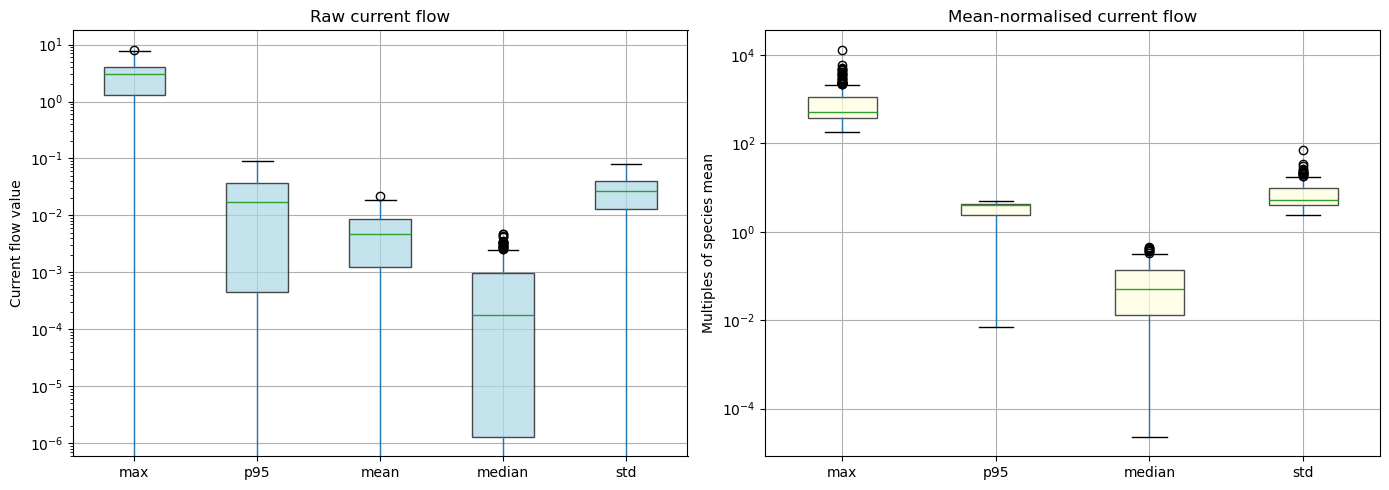

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw (same as before, for comparison)
ax = axes[0]
stats_df[['max', 'p95', 'mean', 'median', 'std']].boxplot(
    ax=ax, vert=True, patch_artist=True,
    boxprops=dict(facecolor='lightblue', alpha=0.7))
ax.set_ylabel('Current flow value')
ax.set_title('Raw current flow')
ax.set_yscale('log')

# Right: mean-normalised
ax = axes[1]
stats_normed_df[['max', 'p95', 'median', 'std']].boxplot(
    ax=ax, vert=True, patch_artist=True,
    boxprops=dict(facecolor='lightyellow', alpha=0.7))
ax.set_ylabel('Multiples of species mean')
ax.set_title('Mean-normalised current flow')
ax.set_yscale('log')

plt.tight_layout()
plt.show()


### Aggregation: mean-normalised, threat-weighted

**Normalisation** (following Omniscape's 'normalized current' concept,
McRae et al. 2016; Landau et al. 2021): per-species current flow is
divided by its own mean, yielding values in 'multiples of species mean'.
This preserves bottleneck magnitude while making species comparable.
Species with zero mean current (< 2 connected components) are excluded.

**Species weighting**: Swiss Red List threat-level weights (CR=4, EN=3, VU=2, NT=1).
More threatened species contribute proportionally more to the priority
surface, reflecting their greater conservation urgency.

**Priority score**: `(weighted_mean_suitability + weighted_mean_current) / 2`
— equal weight to habitat quality and connectivity.

In [5]:
# Swiss Red List threat-level weights
CH_WEIGHTS = {
    'CR': 4,
    'EN': 3,
    'VU': 2,
    'NT': 1,
}

# Build a lookup from species name to Red List category
sp_to_cat = dict(zip(species_redlist['scientific_name'], species_redlist['ch_redlist_cat']))

all_suitability = np.zeros(n_patches, dtype=np.float64)
all_current = np.zeros(n_patches, dtype=np.float64)
total_weight = 0.0
included = 0
skipped_zero = 0
cat_included = {'CR': 0, 'EN': 0, 'VU': 0, 'NT': 0}
cat_skipped = {'CR': 0, 'EN': 0, 'VU': 0, 'NT': 0}

for sp in SPECIES:
    key = sp.replace(' ', '_')

    # Suitability
    if key not in scores_npz.files:
        continue
    suit = scores_npz[key]

    # Current flow
    if key not in current_npz.files:
        continue
    current = current_npz[key]

    # Mean-normalise current (Omniscape-style)
    sp_mean = current.mean()
    cat = sp_to_cat.get(sp, 'NT')
    if sp_mean < 1e-12:
        skipped_zero += 1
        cat_skipped[cat] = cat_skipped.get(cat, 0) + 1
        continue
    current_norm = current / sp_mean  # multiples of species mean

    # Get Swiss Red List weight for this species
    w = CH_WEIGHTS.get(cat, 1)

    all_suitability += suit * w
    all_current += current_norm * w
    total_weight += w
    included += 1
    cat_included[cat] = cat_included.get(cat, 0) + 1

# Weighted average across species
mean_suitability = all_suitability / total_weight
mean_current = all_current / total_weight

# Combined priority score
priority_score = (mean_suitability + mean_current) / 2

print(f'Species included: {included} ({int(total_weight)} weight-units)')
print(f'Species skipped (zero current): {skipped_zero}')
print()
print(f'{"Category":<12} {"Included":<10} {"Skipped":<10} {"Weight":<8}')
print(f'{"-"*12} {"-"*10} {"-"*10} {"-"*8}')
for cat in ['CR', 'EN', 'VU', 'NT']:
    print(f'{cat:<12} {cat_included[cat]:<10} {cat_skipped[cat]:<10} {CH_WEIGHTS[cat]:<8}')
print()
print(f'Mean suitability: {mean_suitability.mean():.4f} (max {mean_suitability.max():.4f})')
print(f'Mean current:     {mean_current.mean():.4f} (max {mean_current.max():.4f})')
print(f'Priority score:   {priority_score.mean():.4f} (max {priority_score.max():.4f})')

Species included: 241 (358 weight-units)
Species skipped (zero current): 44

Category     Included   Skipped    Weight  
------------ ---------- ---------- --------
CR           2          0          4       
EN           17         3          3       
VU           77         16         2       
NT           145        25         1       

Mean suitability: 0.1160 (max 0.5652)
Mean current:     1.0000 (max 230.6253)
Priority score:   0.5580 (max 115.5824)


In [6]:
# Build a DataFrame of all species with their inclusion status
species_status_rows = []
for sp in SPECIES:
    key = sp.replace(' ', '_')
    cat = sp_to_cat.get(sp, 'NT')
    has_scores = key in scores_npz.files
    has_current = key in current_npz.files
    if has_current:
        raw_mean = float(current_npz[key].mean())
    else:
        raw_mean = 0.0
    included_flag = has_scores and has_current and raw_mean > 1e-12
    species_status_rows.append({
        'scientific_name': sp,
        'ch_redlist_cat': cat,
        'weight': CH_WEIGHTS.get(cat, 1),
        'included_in_priority': included_flag,
        'reason_excluded': (
            '' if included_flag else
            'no suitability scores' if not has_scores else
            'no current flow data' if not has_current else
            'zero current (< 2 clusters of size >= 3)'
        ),
        'raw_current_mean': raw_mean,
    })

species_status_df = pd.DataFrame(species_status_rows)
species_status_df = species_status_df.sort_values(
    ['included_in_priority', 'ch_redlist_cat', 'scientific_name'],
    ascending=[False, True, True],
    key=lambda col: (
        pd.Categorical(col, categories=['CR','EN','VU','NT'], ordered=True)
        if col.name == 'ch_redlist_cat' else col
    )
)

# Save to CSV for reproducibility
csv_path = f'{output_dir}/gap_analysis_species_inclusion.csv'
species_status_df.to_csv(csv_path, index=False)
print(f'Saved species inclusion list to: {csv_path}')
print(f'  Total species: {len(species_status_df)}')
print(f'  Included: {species_status_df["included_in_priority"].sum()}')
print(f'  Excluded: {(~species_status_df["included_in_priority"]).sum()}')
print()

# Show compact summary in notebook: list CR+EN, counts only for VU+NT
inc = species_status_df[species_status_df['included_in_priority']]
for cat in ['CR', 'EN']:
    subset = inc[inc['ch_redlist_cat'] == cat]
    if len(subset) == 0:
        continue
    print(f'--- {cat} ({len(subset)} species, weight={CH_WEIGHTS[cat]}) ---')
    for _, row in subset.iterrows():
        print(f'  {row["scientific_name"]}')
    print()

for cat in ['VU', 'NT']:
    subset = inc[inc['ch_redlist_cat'] == cat]
    print(f'--- {cat}: {len(subset)} species (weight={CH_WEIGHTS[cat]}) — see CSV for full list ---')

Saved species inclusion list to: gap_analysis_output/gap_analysis_species_inclusion.csv
  Total species: 285
  Included: 241
  Excluded: 44

--- CR (2 species, weight=4) ---
  Oenanthe lachenalii
  Typha minima

--- EN (17 species, weight=3) ---
  Agrostemma githago
  Aristolochia clematitis
  Eryngium campestre
  Fritillaria meleagris
  Gagea villosa
  Galeopsis segetum
  Galium saxatile
  Gladiolus palustris
  Iberis amara
  Leonurus cardiaca
  Odontites vernus
  Ophrys sphegodes
  Pulsatilla vulgaris
  Rosa gallica
  Scrophularia auriculata
  Verbascum pulverulentum
  Veronica prostrata

--- VU: 77 species (weight=2) — see CSV for full list ---
--- NT: 145 species (weight=1) — see CSV for full list ---


### Overlay with protected areas

IUCN Protected Area Management Categories differ substantially in protection
strength. We split into two tiers:

- **Strict protection** (Ia, Ib, II, III): areas managed primarily for
  biodiversity conservation with minimal human use.
- **Managed protection** (IV, V, VI): areas allowing increasing levels of
  human use and management intervention.

Sites with `Not Assigned` or `Not Reported` categories are excluded from
the strict tier but included in an overall 'any protection' set.

This distinction matters because a Category V 'Protected Landscape' permits
agriculture and settlement, offering far weaker habitat safeguards than a
Category Ia strict nature reserve.

In [7]:
import geopandas as gpd
import rioxarray
from s3_utils import load_zarr
from rasterio.features import rasterize
from rasterio.transform import from_bounds

# Load protected areas
pa = gpd.read_file('protected_areas_ch.geojson')
print(f'Protected areas: {len(pa)}')
print(f'Categories: {pa["iucn_cat"].value_counts().to_dict()}')

# Define protection tiers
STRICT_CATEGORIES = {'Ia', 'Ib', 'II', 'III'}
MANAGED_CATEGORIES = {'IV', 'V', 'VI'}
# 'Not Assigned' and 'Not Reported' go into 'any' but not strict/managed

pa_strict = pa[pa['iucn_cat'].isin(STRICT_CATEGORIES)]
pa_managed = pa[pa['iucn_cat'].isin(MANAGED_CATEGORIES)]
print(f'\nStrict protection (Ia–III): {len(pa_strict):,} areas')
print(f'Managed protection (IV–VI): {len(pa_managed):,} areas')
print(f'Unclassified (Not Assigned/Not Reported): {len(pa) - len(pa_strict) - len(pa_managed):,} areas')

# Load patch labels raster
patch_labels_da = load_zarr(
    config.S3_PROCESSED + '/patches/patch_labels_30m.zarr',
    name='patch_label',
)
patch_labels = patch_labels_da.values
h, w = patch_labels.shape
bounds = patch_labels_da.rio.bounds()
raster_transform = from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], w, h)

# Helper: rasterise a subset of PA polygons and compute patch-level overlap
def pa_to_patch_set(pa_subset):
    shapes = [(geom, 1) for geom in pa_subset.geometry if geom is not None]
    if not shapes:
        return set()
    mask = rasterize(
        shapes, out_shape=(h, w), transform=raster_transform,
        fill=0, dtype=np.uint8
    )
    flat = mask[valid].astype(np.float64)
    overlap_sum = np.bincount(patch_ids_flat, weights=flat, minlength=n_patches)
    frac = np.zeros(n_patches)
    frac[nonzero_mask] = overlap_sum[nonzero_mask] / total_count[nonzero_mask]
    return set(np.where(frac > 0.0)[0])

# Compute patch-level counts (shared across all tiers)
valid = patch_labels >= 0
patch_ids_flat = patch_labels[valid].astype(np.int64)
total_count = np.bincount(patch_ids_flat, minlength=n_patches)
nonzero_mask = total_count > 0

# Compute per-tier patch sets
strict_patches = pa_to_patch_set(pa_strict)
managed_patches = pa_to_patch_set(pa_managed)
# 'Any protection' = all PA polygons (including unclassified)
protected_patches = pa_to_patch_set(pa)

print(f'\nPatch coverage (before Swiss-only filter):')
print(f'  Strict (Ia–III):   {len(strict_patches):,} / {n_patches:,} ({len(strict_patches)/n_patches*100:.1f}%)')
print(f'  Managed (IV–VI):   {len(managed_patches):,} / {n_patches:,} ({len(managed_patches)/n_patches*100:.1f}%)')
print(f'  Any protection:    {len(protected_patches):,} / {n_patches:,} ({len(protected_patches)/n_patches*100:.1f}%)')

Protected areas: 10522
Categories: {'IV': 6629, 'Not Assigned': 3302, 'Ia': 553, 'Not Reported': 37, 'VI': 1}

Strict protection (Ia–III): 553 areas
Managed protection (IV–VI): 6,630 areas
Unclassified (Not Assigned/Not Reported): 3,339 areas

Patch coverage (before Swiss-only filter):
  Strict (Ia–III):   1,092 / 166,464 (0.7%)
  Managed (IV–VI):   14,145 / 166,464 (8.5%)
  Any protection:    18,948 / 166,464 (11.4%)


### Restrict to Switzerland

In [8]:
# Load Switzerland boundary
ch_boundary = gpd.read_file('switzerland_boundary.geojson')
ch_shapes = [(geom, 1) for geom in ch_boundary.geometry if geom is not None]
ch_mask = rasterize(
    ch_shapes, out_shape=(h, w), transform=raster_transform,
    fill=0, dtype=np.uint8
)

ch_flat = ch_mask[valid].astype(np.float64)
ch_sum = np.bincount(patch_ids_flat, weights=ch_flat, minlength=n_patches)
frac_in_ch = np.zeros(n_patches)
frac_in_ch[nonzero_mask] = ch_sum[nonzero_mask] / total_count[nonzero_mask]

swiss_patches = set(np.where(frac_in_ch > 0.5)[0])
n_swiss = len(swiss_patches)
print(f'Swiss patches: {n_swiss:,} / {n_patches:,} ({n_swiss/n_patches*100:.1f}%)')

# Restrict all protection sets to Swiss patches
strict_patches = strict_patches & swiss_patches
managed_patches = managed_patches & swiss_patches
protected_patches = protected_patches & swiss_patches

print(f'\nSwiss protection coverage:')
print(f'  Strict (Ia–III):   {len(strict_patches):,} / {n_swiss:,} ({len(strict_patches)/n_swiss*100:.1f}%)')
print(f'  Managed (IV–VI):   {len(managed_patches):,} / {n_swiss:,} ({len(managed_patches)/n_swiss*100:.1f}%)')
print(f'  Any protection:    {len(protected_patches):,} / {n_swiss:,} ({len(protected_patches)/n_swiss*100:.1f}%)')
print(f'  Unprotected:       {n_swiss - len(protected_patches):,} / {n_swiss:,} ({(n_swiss - len(protected_patches))/n_swiss*100:.1f}%)')

Swiss patches: 65,298 / 166,464 (39.2%)

Swiss protection coverage:
  Strict (Ia–III):   1,081 / 65,298 (1.7%)
  Managed (IV–VI):   13,965 / 65,298 (21.4%)
  Any protection:    18,695 / 65,298 (28.6%)
  Unprotected:       46,603 / 65,298 (71.4%)


### Analysis 1: Protection effectiveness

Compare IUCN-weighted mean habitat suitability across protection tiers.
Ratio > 1 means the tier covers better-than-average habitat for threatened species.

We report separately for strict (Ia–III), managed (IV–VI), and unprotected patches.

In [9]:
strict_arr = np.array(list(strict_patches))
managed_arr = np.array(list(managed_patches))
protected_arr = np.array(list(protected_patches))
unprotected_arr = np.array(list(swiss_patches - protected_patches))

print('=== Analysis 1: Protection Effectiveness (Switzerland only) ===')
print(f'Strict (Ia–III):  {len(strict_arr):,} patches ({len(strict_arr)/n_swiss*100:.1f}%)')
print(f'Managed (IV–VI):  {len(managed_arr):,} patches ({len(managed_arr)/n_swiss*100:.1f}%)')
print(f'Any protection:   {len(protected_arr):,} patches ({len(protected_arr)/n_swiss*100:.1f}%)')
print(f'Unprotected:      {len(unprotected_arr):,} patches ({len(unprotected_arr)/n_swiss*100:.1f}%)')

# Per-species suitability by protection tier
# Show individual species for CR + EN only; aggregate VU + NT
print(f'\n{"Species":30s} {"Cat":>4s} {"Strict":>8s} {"Managed":>9s} {"Unprot":>8s} {"Strict/Unprot":>14s}')
print('-' * 80)

vu_nt_ratios = []  # collect for aggregate summary

for sp in SPECIES:
    key = sp.replace(' ', '_')
    if key not in scores_npz.files:
        continue
    suit = scores_npz[key]
    cat = sp_to_cat.get(sp, '?')
    s_strict = suit[strict_arr].mean() if len(strict_arr) > 0 else 0
    s_managed = suit[managed_arr].mean() if len(managed_arr) > 0 else 0
    s_out = suit[unprotected_arr].mean()
    ratio = s_strict / max(s_out, 1e-8)

    if cat in ('CR', 'EN'):
        print(f'{sp:30s} {cat:>4s} {s_strict:>8.4f} {s_managed:>9.4f} {s_out:>8.4f} {ratio:>12.2f}x')
    else:
        vu_nt_ratios.append(ratio)

if vu_nt_ratios:
    print(f'{"--- VU+NT (" + str(len(vu_nt_ratios)) + " spp) ---":30s} {"":>4s} {"":>8s} {"":>9s} {"":>8s} '
          f'{np.mean(vu_nt_ratios):>10.2f}x avg')

# Aggregate across all species
s_strict_all = mean_suitability[strict_arr].mean() if len(strict_arr) > 0 else 0
s_managed_all = mean_suitability[managed_arr].mean() if len(managed_arr) > 0 else 0
s_out_all = mean_suitability[unprotected_arr].mean()
print(f'{"--- ALL SPECIES ---":30s} {"":>4s} {s_strict_all:>8.4f} {s_managed_all:>9.4f} {s_out_all:>8.4f} {s_strict_all/max(s_out_all,1e-8):>12.2f}x')
print(f'\nInterpretation: Strict PAs are {s_strict_all/max(s_out_all,1e-8):.2f}x better habitat on average.')
print(f'Managed PAs are {s_managed_all/max(s_out_all,1e-8):.2f}x vs unprotected.')

=== Analysis 1: Protection Effectiveness (Switzerland only) ===
Strict (Ia–III):  1,081 patches (1.7%)
Managed (IV–VI):  13,965 patches (21.4%)
Any protection:   18,695 patches (28.6%)
Unprotected:      46,603 patches (71.4%)

Species                         Cat   Strict   Managed   Unprot  Strict/Unprot
--------------------------------------------------------------------------------
Agrostemma githago               EN   0.1058    0.1561   0.2197         0.48x
Aristolochia clematitis          EN   0.0612    0.0882   0.1043         0.59x
Bromus racemosus                 EN   0.0075    0.0331   0.0272         0.27x
Eryngium campestre               EN   0.0035    0.0540   0.0583         0.06x
Fritillaria meleagris            EN   0.1543    0.1676   0.2363         0.65x
Gagea villosa                    EN   0.0074    0.0749   0.0687         0.11x
Galeopsis segetum                EN   0.0385    0.0945   0.0870         0.44x
Galium saxatile                  EN   0.1177    0.0927   0.0530    

### Analysis 2: Expansion priorities

High-connectivity patches that are currently unprotected = priority
candidates for new reserves. We also check how many high-connectivity
patches fall into managed (IV–VI) areas, since those provide weaker
guarantees and could benefit from upgraded protection status.

In [10]:
swiss_arr = np.array(list(swiss_patches))
swiss_current = mean_current[swiss_arr]

# Pixel area: 30m x 30m = 900 m² = 0.0009 km²
PIXEL_AREA_KM2 = 900 / 1e6

def patches_area_km2(patch_set):
    """Compute total area in km² for a set of patch IDs using pixel counts."""
    return sum(total_count[p] for p in patch_set) * PIXEL_AREA_KM2

swiss_area_km2 = patches_area_km2(swiss_patches)

# Top 5% connectivity — high priority
p95_current = np.percentile(swiss_current[swiss_current > 0], 95)
high_connectivity = set(np.where(mean_current >= p95_current)[0]) & swiss_patches

hc_strict = high_connectivity & strict_patches
hc_managed = high_connectivity & managed_patches
hc_protected = high_connectivity & protected_patches
hc_unprotected = high_connectivity - protected_patches
hc_area = patches_area_km2(high_connectivity)

print(f'Swiss patches total area: {swiss_area_km2:,.0f} km²')
print(f'\nHigh-priority patches (top 5%, {hc_area:,.0f} km², {hc_area/swiss_area_km2*100:.1f}% of CH): {len(high_connectivity):,}')
print(f'  Strictly protected (Ia–III): {len(hc_strict):,} ({len(hc_strict)/len(high_connectivity)*100:.1f}%)')
print(f'  Managed only (IV–VI):        {len(hc_managed - hc_strict):,} ({len(hc_managed - hc_strict)/len(high_connectivity)*100:.1f}%)')
print(f'  Any protection:              {len(hc_protected):,} ({len(hc_protected)/len(high_connectivity)*100:.1f}%)')
print(f'  UNPROTECTED:                 {len(hc_unprotected):,} ({len(hc_unprotected)/len(high_connectivity)*100:.1f}%)')

# Top 1% — critical corridors
p99_current = np.percentile(swiss_current[swiss_current > 0], 99)
critical_corridors = set(np.where(mean_current >= p99_current)[0]) & swiss_patches
cc_strict = critical_corridors & strict_patches
cc_managed = critical_corridors & managed_patches
cc_unprotected = critical_corridors - protected_patches
cc_area = patches_area_km2(critical_corridors)

print(f'\nCritical corridor patches (top 1%, {cc_area:,.0f} km², {cc_area/swiss_area_km2*100:.2f}% of CH): {len(critical_corridors):,}')
print(f'  Strictly protected: {len(cc_strict):,} ({len(cc_strict)/len(critical_corridors)*100:.1f}%)')
print(f'  Managed only:       {len(cc_managed - cc_strict):,} ({len(cc_managed - cc_strict)/len(critical_corridors)*100:.1f}%)')
print(f'  UNPROTECTED:        {len(cc_unprotected):,} ({len(cc_unprotected)/len(critical_corridors)*100:.1f}%)')

cc_unprot_area = patches_area_km2(cc_unprotected)
print(f'\nPriority actions:')
print(f'  1. {len(cc_unprotected):,} unprotected critical corridor patches ({cc_unprot_area:,.0f} km²) → new protection needed')
print(f'  2. {len(cc_managed - cc_strict):,} managed-only critical corridor patches → consider upgrading to strict status')

Swiss patches total area: 57,954 km²

High-priority patches (top 5%, 21,019 km², 36.3% of CH): 3,265
  Strictly protected (Ia–III): 136 (4.2%)
  Managed only (IV–VI):        1,420 (43.5%)
  Any protection:              1,923 (58.9%)
  UNPROTECTED:                 1,342 (41.1%)

Critical corridor patches (top 1%, 12,947 km², 22.34% of CH): 653
  Strictly protected: 42 (6.4%)
  Managed only:       381 (58.3%)
  UNPROTECTED:        168 (25.7%)

Priority actions:
  1. 168 unprotected critical corridor patches (866 km²) → new protection needed
  2. 381 managed-only critical corridor patches → consider upgrading to strict status


### Visualise priority surface

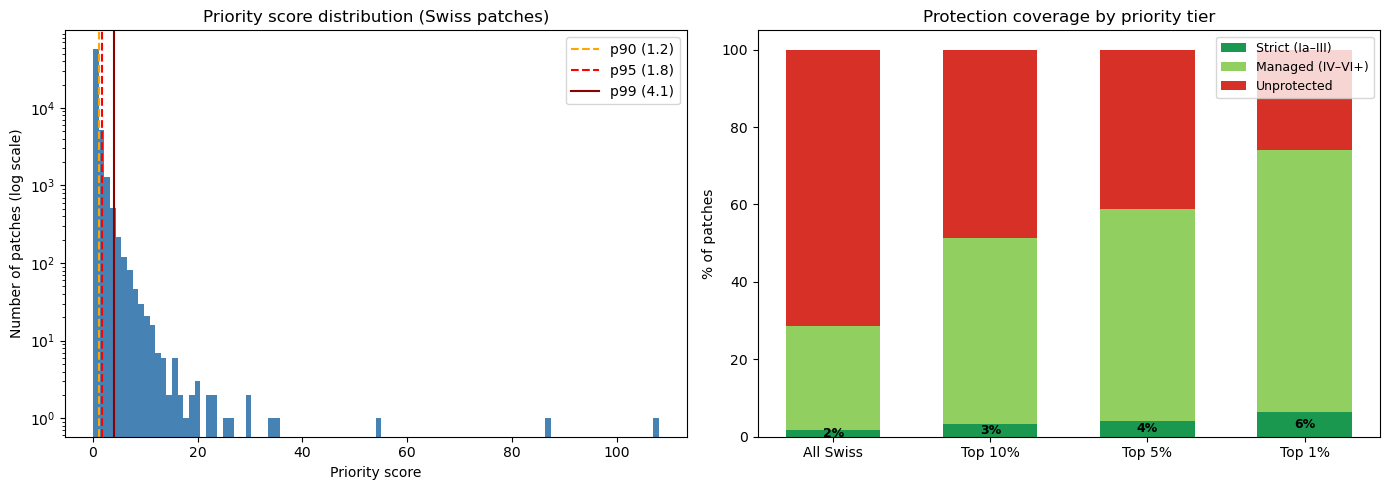

In [11]:
# Summary visualisation: priority score histogram + protection tiers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Priority score distribution (log-scaled y-axis)
ax = axes[0]
swiss_priority = priority_score[swiss_arr]
sp_pos = swiss_priority[swiss_priority > 0]
ax.hist(sp_pos, bins=100, color='steelblue', edgecolor='none')
ax.set_yscale('log')
p90 = np.percentile(sp_pos, 90)
p95 = np.percentile(sp_pos, 95)
p99 = np.percentile(sp_pos, 99)
ax.axvline(p90, color='orange', linestyle='--', label=f'p90 ({p90:.1f})')
ax.axvline(p95, color='red', linestyle='--', label=f'p95 ({p95:.1f})')
ax.axvline(p99, color='darkred', linestyle='-', label=f'p99 ({p99:.1f})')
ax.set_xlabel('Priority score')
ax.set_ylabel('Number of patches (log scale)')
ax.set_title('Priority score distribution (Swiss patches)')
ax.legend()

# Panel 2: Protection coverage by priority tier — split by strict vs managed
ax = axes[1]
tiers = ['All Swiss', 'Top 10%', 'Top 5%', 'Top 1%']
pcts_strict = []
pcts_managed = []
pcts_unprotected = []
for pct_thresh in [0, 90, 95, 99]:
    if pct_thresh == 0:
        tier_patches = swiss_patches
    else:
        thresh = np.percentile(swiss_priority[swiss_priority > 0], pct_thresh)
        tier_patches = set(np.where(priority_score >= thresh)[0]) & swiss_patches
    n_tier = len(tier_patches)
    n_strict = len(tier_patches & strict_patches)
    n_managed_only = len(tier_patches & managed_patches - tier_patches & strict_patches)
    n_unprot = n_tier - len(tier_patches & protected_patches)
    pcts_strict.append(n_strict / n_tier * 100 if n_tier > 0 else 0)
    pcts_managed.append((len(tier_patches & protected_patches) - n_strict) / n_tier * 100 if n_tier > 0 else 0)
    pcts_unprotected.append(n_unprot / n_tier * 100 if n_tier > 0 else 0)

import numpy as np
x = np.arange(len(tiers))
width = 0.6
p1 = ax.bar(x, pcts_strict, width, label='Strict (Ia–III)', color='#1a9850')
p2 = ax.bar(x, pcts_managed, width, bottom=pcts_strict, label='Managed (IV–VI+)', color='#91cf60')
bottoms = [s + m for s, m in zip(pcts_strict, pcts_managed)]
p3 = ax.bar(x, pcts_unprotected, width, bottom=bottoms, label='Unprotected', color='#d73027')

ax.set_xticks(x)
ax.set_xticklabels(tiers)
ax.set_ylabel('% of patches')
ax.set_title('Protection coverage by priority tier')
ax.set_ylim(0, 105)
ax.legend(loc='upper right', fontsize=9)

# Annotate strict % on each bar
for i, pct in enumerate(pcts_strict):
    ax.text(i, pct/2, f'{pct:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Map 1: Full Switzerland — priority surface + protected areas

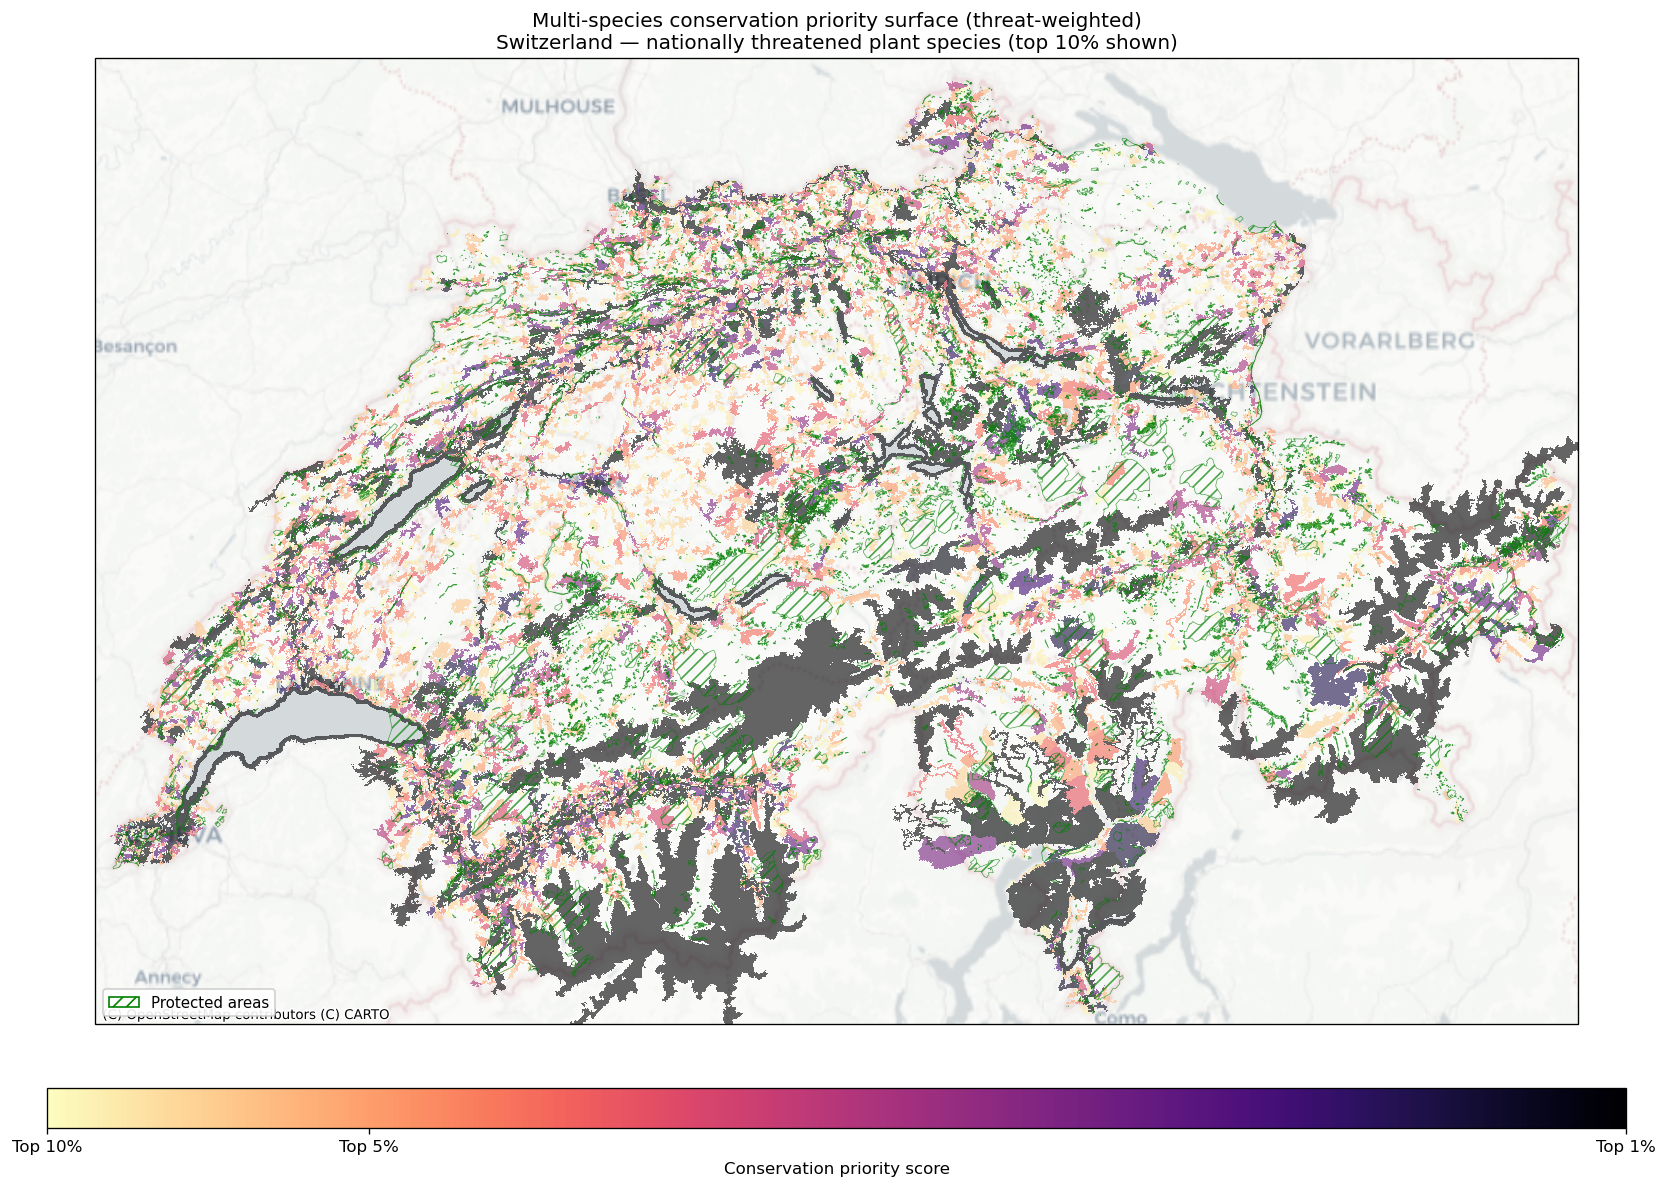

In [12]:
import numpy.ma as ma
import contextily as cx
import cartopy.crs as ccrs
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

# Switzerland extent (approx)
ch_extent = {'lon_min': 5.9, 'lon_max': 10.5, 'lat_min': 45.8, 'lat_max': 47.85}

# Map priority score onto the raster
priority_raster = np.full((h, w), np.nan, dtype=np.float32)
priority_raster[valid] = priority_score[patch_ids_flat]

# Map protection status onto the raster (2 = strict, 1 = managed/other, 0 = not)
prot_raster = np.zeros((h, w), dtype=np.float32)
protected_set_arr = np.zeros(n_patches, dtype=np.float32)
for p in strict_patches:
    protected_set_arr[p] = 2.0
for p in (protected_patches - strict_patches):
    if protected_set_arr[p] == 0:
        protected_set_arr[p] = 1.0
prot_raster[valid] = protected_set_arr[patch_ids_flat]

# Also mark Swiss boundary
swiss_set_arr = np.zeros(n_patches, dtype=np.float32)
for p in swiss_patches:
    swiss_set_arr[p] = 1.0

# Mask to Switzerland
ch_pixel_mask = np.zeros((h, w), dtype=bool)
ch_pixel_mask[valid] = swiss_set_arr[patch_ids_flat] > 0.5

priority_masked = ma.masked_where(~ch_pixel_mask | np.isnan(priority_raster) | (priority_raster < np.percentile(priority_score[priority_score > 0], 90)), priority_raster)

# Colormaps
priority_cmap = 'magma_r'

fig, ax = plt.subplots(figsize=(14, 10),
                       subplot_kw={'projection': ccrs.PlateCarree()},
                       dpi=120)
ax.set_extent([ch_extent['lon_min'], ch_extent['lon_max'],
               ch_extent['lat_min'], ch_extent['lat_max']])

cx.add_basemap(ax, crs=ccrs.PlateCarree(),
               source=cx.providers.CartoDB.Positron, zoom=8)

extent = [bounds[0], bounds[2], bounds[1], bounds[3]]

# Priority surface
p95_val = np.percentile(priority_score[priority_score > 0], 95)
p99_val = np.percentile(priority_score[priority_score > 0], 99)
ax.imshow(priority_masked, cmap=priority_cmap, vmin=np.percentile(priority_score[priority_score > 0], 90), vmax=p99_val,
          alpha=0.6, extent=extent, origin='upper',
          interpolation='nearest', transform=ccrs.PlateCarree())

# Protected areas — dissolved + simplified for speed, then hatched for clarity
pa_dissolved = pa.dissolve().simplify(0.002)
pa_dissolved.plot(ax=ax, facecolor='none', edgecolor='green', linewidth=0.4, alpha=0.7,
                  hatch='///', transform=ccrs.PlateCarree())

# Colorbar
import matplotlib.cm as mcm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
p90_val = np.percentile(priority_score[priority_score > 0], 90)
sm = mcm.ScalarMappable(cmap=priority_cmap, norm=Normalize(vmin=p90_val, vmax=p99_val))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal',
                    fraction=0.04, pad=0.06, aspect=40)
cbar.set_label('Conservation priority score', fontsize=10)
cbar.set_ticks([p90_val, p95_val, p99_val])
cbar.set_ticklabels(['Top 10%', 'Top 5%', 'Top 1%'])

# PA legend
ax.legend(handles=[Patch(facecolor='none', edgecolor='green', linewidth=1, hatch='///', label='Protected areas')],
          loc='lower left', fontsize=9, framealpha=0.9)
ax.set_title('Multi-species conservation priority surface (threat-weighted)\n'
             'Switzerland — nationally threatened plant species (top 10% shown)', fontsize=12)
plt.tight_layout()
plt.show()

### Map 2: Contrasting regions — Alpine (well-protected) vs Mittelland (gap)

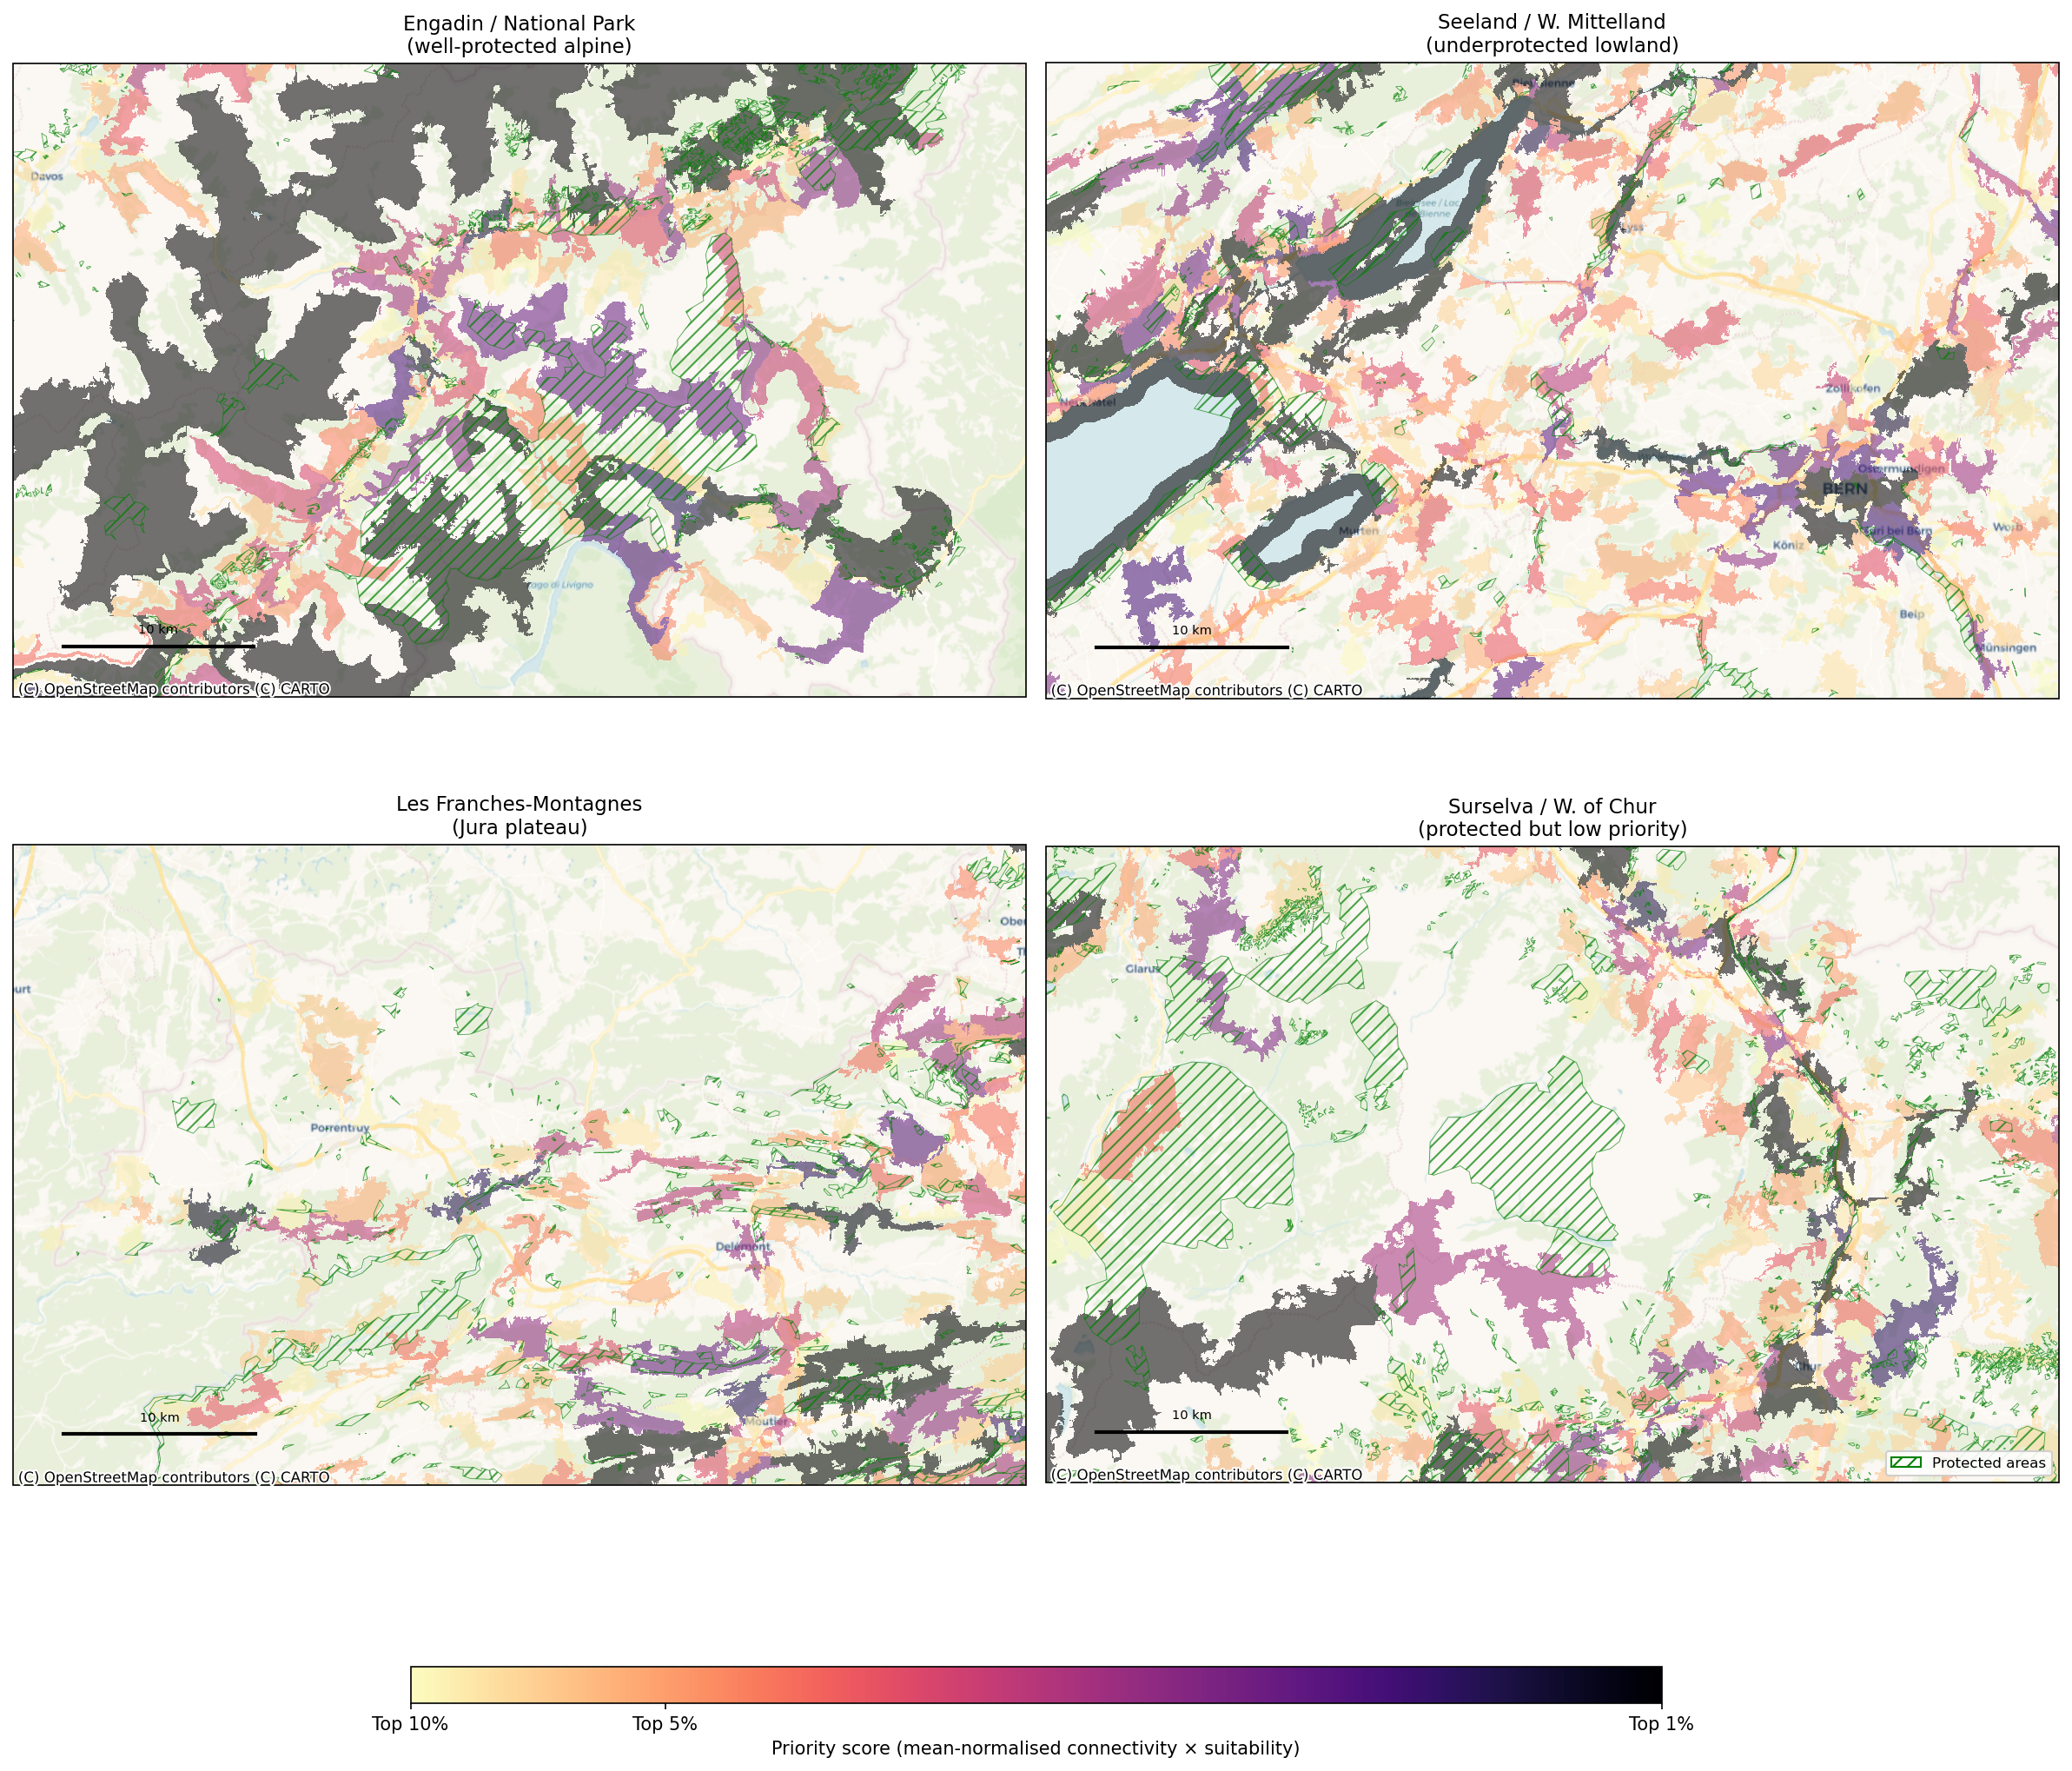

In [20]:
# Four contrasting ROIs:
# 1. Engadin / Swiss National Park area (well-protected alpine)
# 2. Western Mittelland / Seeland (lowland gap)
# 3. Les Franches-Montagnes (Jura plateau)
# 4. Surselva
rois = [
    {'name': 'Engadin / National Park\n(well-protected alpine)',
     'lon_min': 9.8, 'lon_max': 10.5, 'lat_min': 46.55, 'lat_max': 46.85},
    {'name': 'Seeland / W. Mittelland\n(underprotected lowland)',
     'lon_min': 6.9, 'lon_max': 7.6, 'lat_min': 46.85, 'lat_max': 47.15},
    {'name': 'Les Franches-Montagnes\n(Jura plateau)',
     'lon_min': 6.85, 'lon_max': 7.55, 'lat_min': 47.25, 'lat_max': 47.55},
    {'name': 'Surselva / W. of Chur\n(protected but low priority)',
     'lon_min': 9.0, 'lon_max': 9.7, 'lat_min': 46.80, 'lat_max': 47.10},
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         dpi=150)
axes = axes.flatten()

# Only show priority colors for top 10% patches (medium and above)
p90_priority = np.percentile(priority_score[priority_score > 0], 90)

for ax, roi in zip(axes, rois):
    ax.set_extent([roi['lon_min'], roi['lon_max'],
                   roi['lat_min'], roi['lat_max']])

    cx.add_basemap(ax, crs=ccrs.PlateCarree(),
                   source=cx.providers.CartoDB.Voyager, zoom=11)

    # Clip patch labels to ROI
    label_roi = patch_labels_da.sel(
        y=slice(roi['lat_max'], roi['lat_min']),
        x=slice(roi['lon_min'], roi['lon_max']),
    )
    labels_arr = label_roi.values
    roi_valid = labels_arr >= 0
    roi_extent = [roi['lon_min'], roi['lon_max'], roi['lat_min'], roi['lat_max']]

    # Priority in ROI (only Swiss patches)
    priority_roi = np.zeros_like(labels_arr, dtype=np.float32)
    priority_roi[roi_valid] = priority_score[labels_arr[roi_valid]]
    is_swiss_roi = np.zeros_like(labels_arr, dtype=bool)
    is_swiss_roi[roi_valid] = swiss_set_arr[labels_arr[roi_valid]] > 0.5
    priority_roi_masked = ma.masked_where(~roi_valid | ~is_swiss_roi | (priority_roi < p90_priority), priority_roi)

    ax.imshow(priority_roi_masked, cmap=priority_cmap, vmin=p90_priority, vmax=p99_val,
              alpha=0.55, extent=roi_extent, origin='upper',
              interpolation='nearest', transform=ccrs.PlateCarree())

    # Protected areas — semi-transparent green fill (clipped to ROI for speed)
    pa_roi = pa.cx[roi['lon_min']:roi['lon_max'], roi['lat_min']:roi['lat_max']]
    if len(pa_roi) > 0:
        pa_roi.dissolve().simplify(0.001).plot(ax=ax, facecolor='none', edgecolor='green',
                              linewidth=0.4, alpha=0.7, hatch='///',
                              transform=ccrs.PlateCarree())

    ax.set_title(roi['name'], fontsize=11)

    # Scale bar (10 km)
    # At ~47°N latitude, 1° lon ≈ 75 km, so 10 km ≈ 0.133°
    import math
    lat_mid = (roi['lat_min'] + roi['lat_max']) / 2
    km_per_deg_lon = 111.32 * math.cos(math.radians(lat_mid))
    bar_len_deg = 10.0 / km_per_deg_lon  # 10 km in degrees longitude
    bar_x = roi['lon_min'] + 0.05 * (roi['lon_max'] - roi['lon_min'])
    bar_y = roi['lat_min'] + 0.08 * (roi['lat_max'] - roi['lat_min'])
    ax.plot([bar_x, bar_x + bar_len_deg], [bar_y, bar_y],
            color='black', linewidth=2, transform=ccrs.PlateCarree())
    ax.text(bar_x + bar_len_deg / 2, bar_y + 0.005, '10 km',
            ha='center', va='bottom', fontsize=7, transform=ccrs.PlateCarree())

# Colorbar for priority score — manually placed below figure
import matplotlib.cm as mcm
from matplotlib.colors import Normalize
sm = mcm.ScalarMappable(cmap=priority_cmap, norm=Normalize(vmin=p90_priority, vmax=p99_val))
sm.set_array([])
plt.tight_layout(rect=[0, 0.06, 1, 1])  # leave room at bottom
cbar_ax = fig.add_axes([0.2, 0.02, 0.6, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Priority score (mean-normalised connectivity × suitability)', fontsize=10)
p95_priority = np.percentile(priority_score[priority_score > 0], 95)
cbar.set_ticks([p90_priority, p95_priority, p99_val])
cbar.set_ticklabels(['Top 10%', 'Top 5%', 'Top 1%'])

# Legend for PA fill
legend_elements = [
    Patch(facecolor='none', edgecolor='green', linewidth=1, hatch='///', label='Protected areas'),
]
axes[-1].legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.9)
plt.show()